<a href="https://colab.research.google.com/github/2326-aar/Task-6/blob/main/KNN_Iris_task6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
Id             

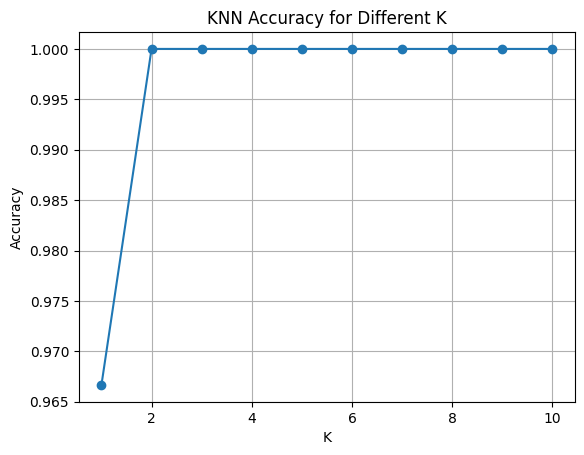

Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


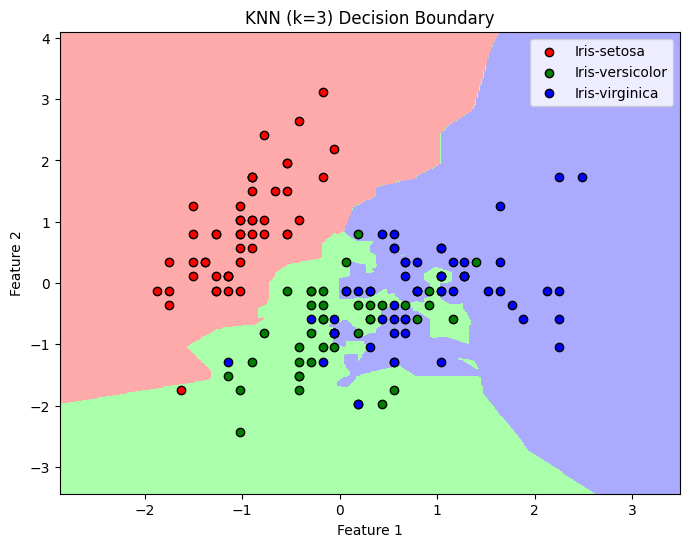

In [10]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder


# Step 2: Load and Explore the Dataset
# Load dataset
df = pd.read_csv("/content/Iris.csv")
# Display the first 5 rows
print(df.head())
# Check basic info
print(df.info())
# Check for missing values
print(df.isnull().sum())

# Drop Id column (not useful for prediction)
df.drop("Id", axis=1, inplace=True)


# Step 3: Prepare the Features and Labels
X = df.iloc[:, :-1].values  # All columns except 'Species'
y = df.iloc[:, -1].values   # Target: Species


# Step 4: Normalize the Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# Step 6: Train and Evaluate KNN Model with Different K values
k_values = range(1, 11)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc:.2f}")


# Step 7: Plot Accuracy vs K
plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Accuracy for Different K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


# Step 8: Evaluate Best Model (let's say k=3 based on previous step)
best_k = 3
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# Step 9: Visualize Decision Boundaries (2 features only)
def plot_decision_boundary(X, y, k):
    # Use only first two features
    X = X[:, :2]
    # Encode target labels into numeric values
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Create KNN and fit
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y_encoded)

    # Set meshgrid limits
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict and reshape
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Define color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']

    # Plot
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    for i, color in zip(np.unique(y_encoded), cmap_bold):
        plt.scatter(X[y_encoded == i, 0], X[y_encoded == i, 1],
                    c=color, label=le.classes_[i], edgecolor='k')

    plt.title(f"KNN (k={k}) Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# Call the function
plot_decision_boundary(X_scaled, y, k=3)
